<a href="https://colab.research.google.com/github/Sriya777/Speech-Processing/blob/main/speechprocessing_Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Speech Processing Lab Assignment-6

Title: Pitch and Formant Estimation using FFT and STFT in Speech Processing.

Sriya Nistala

BL.EN.U4AIE23034

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy.fft import fft

# Load audio
file_path = "/content/drive/MyDrive/sriya.wav"
signal, sr = librosa.load(file_path, sr=None)

print("Sampling Rate:", sr)
print("Signal Length:", len(signal))

Sampling Rate: 48000
Signal Length: 2367360


1.Dataset: Use any speech sample in .wav format. You can record your own voice or download a sample from publicly available datasets (e.g., LJ Speech Dataset, your project speech data)

Q1. Use FFT, to extract and visualize both pitch, harmonics and formants from a speech signal.

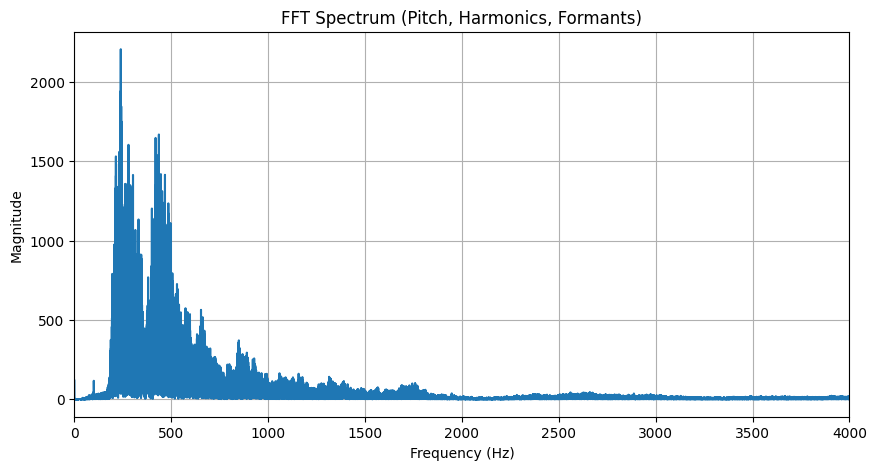

In [3]:
# FFT
N = len(signal)
fft_vals = np.abs(fft(signal))
freqs = np.fft.fftfreq(N, 1/sr)

# Take only positive frequencies
half_N = N // 2
freqs = freqs[:half_N]
fft_vals = fft_vals[:half_N]

# Plot FFT Spectrum
plt.figure(figsize=(10,5))
plt.plot(freqs, fft_vals)
plt.title("FFT Spectrum (Pitch, Harmonics, Formants)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 4000)  # speech range
plt.grid()
plt.show()

Q2. Use STFT, to extract and visualize spectrogram of (i) pitch contour and (ii) formants.

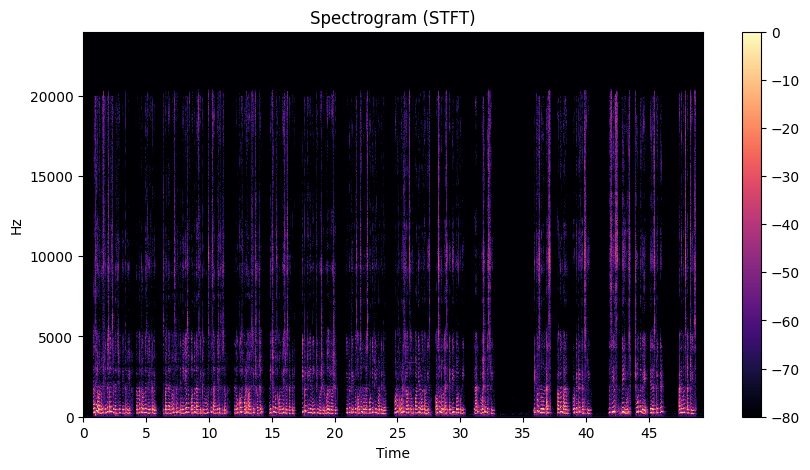

In [4]:
D = librosa.stft(signal)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(10,5))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram (STFT)")
plt.show()

Pitch Contour

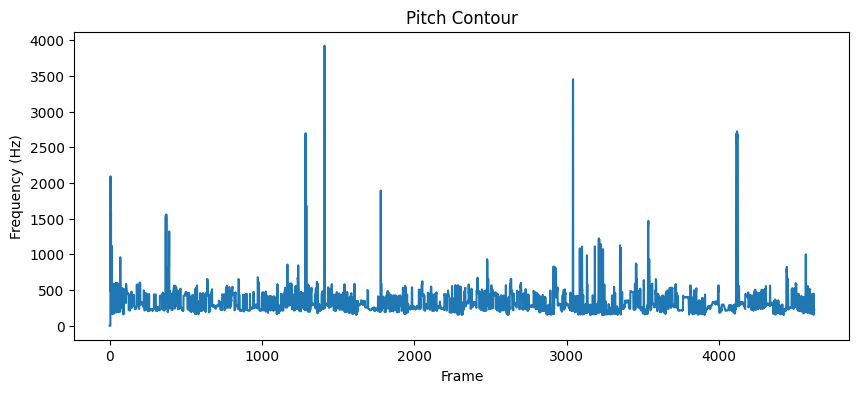

In [5]:
pitch, mag = librosa.piptrack(y=signal, sr=sr)

pitch_values = []
for i in range(pitch.shape[1]):
    index = mag[:, i].argmax()
    pitch_values.append(pitch[index, i])

plt.figure(figsize=(10,4))
plt.plot(pitch_values)
plt.title("Pitch Contour")
plt.xlabel("Frame")
plt.ylabel("Frequency (Hz)")
plt.show()

Formants

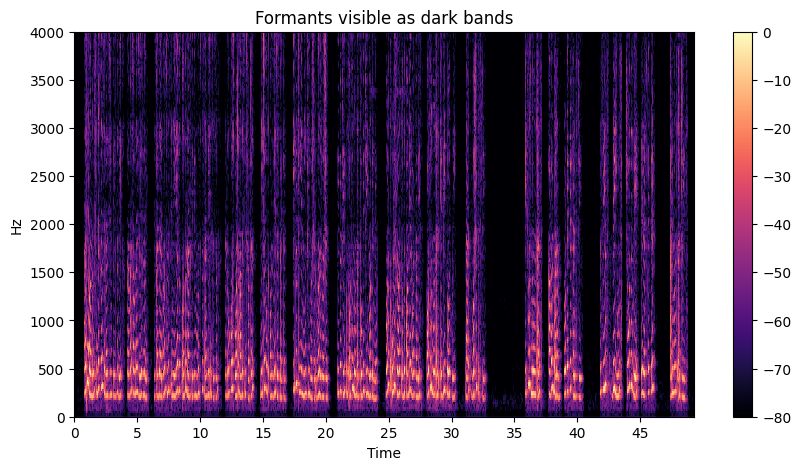

In [6]:
plt.figure(figsize=(10,5))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.title("Formants visible as dark bands")
plt.ylim(0, 4000)
plt.colorbar()
plt.show()

Q3.Analyze whether pitch, harmonics and formants are visually distinguishable based on their frequency characteristics in both FFT and STFT. Comment on your result.

Pitch appears as lowest frequency component (~100–300 Hz)

Harmonics appear as equally spaced peaks in FFT

Formants appear as broad energy bands

In STFT:

Pitch → horizontal fine lines

Formants → thick dark bands

STFT gives time-varying info, FFT gives overall frequency info

Q4.Take narrower and wider window and plot (a) narrowband spectrogram and (b) wideband spectrogram.

Narrowband (Large window → better frequency resolution)

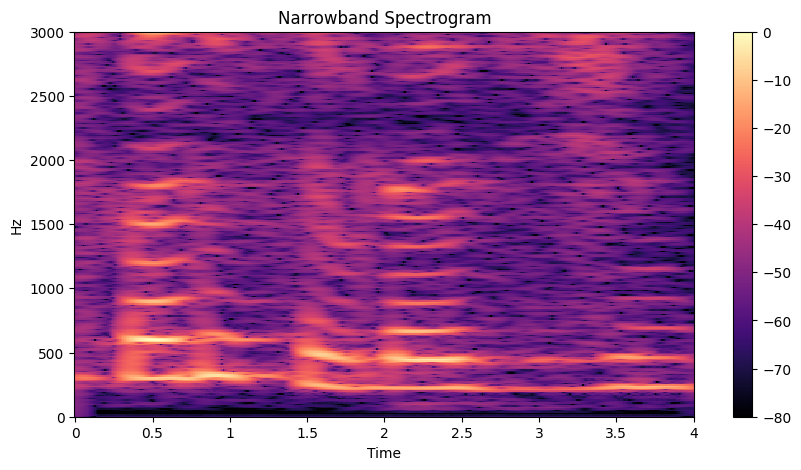

In [17]:
import librosa.effects

# Pre-emphasis (boosts harmonics)
signal_preemph = librosa.effects.preemphasis(signal)

# Take a small voiced segment (IMPORTANT)
start = int(2 * sr)
end = int(3 * sr)
segment = signal_preemph[start:end]

D_narrow = librosa.stft(segment, n_fft=4096, hop_length=128, win_length=4096)
S_db = librosa.amplitude_to_db(np.abs(D_narrow), ref=np.max)

plt.figure(figsize=(10,5))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.ylim(0, 3000)
plt.title("Narrowband Spectrogram")
plt.colorbar()
plt.show()

Wideband (Small window → better time resolution)

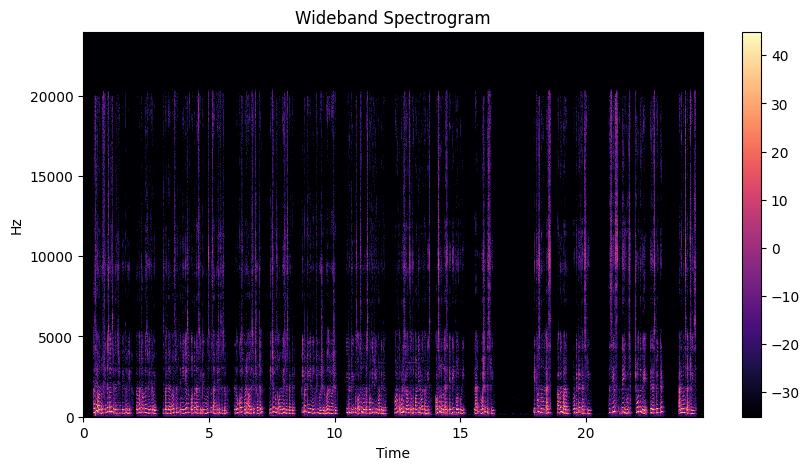

In [16]:
D_wide = librosa.stft(signal, n_fft=4096)

plt.figure(figsize=(10,5))
librosa.display.specshow(librosa.amplitude_to_db(np.abs(D_wide)),
                         sr=sr, x_axis='time', y_axis='hz')
plt.title("Wideband Spectrogram")
plt.colorbar()
plt.show()

Q5.Infer about the result

Narrowband:

Clear harmonics

Poor time resolution

Wideband:

Clear pitch pulses

Better time resolution

Trade-off:

Large window → better frequency detail

Small window → better time detail